# Exploratory Data Analysis — Kickstarter Campaigns
**Group_ID-13** · Words That Fund: Linguistic Patterns in Crowdfunding Campaign Success

### Outline
1. Setup & Data Loading
2. Dataset Overview
3. Missing Values & Data Quality
4. Category Analysis
5. Funding Goal Distribution
6. Pledged Amount Distribution
7. Reached % Distribution
8. Goal vs. Pledged (by outcome & category)
9. Description Length Analysis
10. Description Length vs. Amount Funded


## 1. Setup & Data Loading

In [ ]:
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline

# ── consistent style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (10, 4)})

BLUE, RED, PALETTE = "#477ADA", "#D65F5F", ["#4878CF", "#D65F5F"]


In [27]:
df = pd.read_csv("Kickstarter_dataset_14-04.csv", index_col=0)

# Parse token lists
def parse_tokens(cell):
    try:
        return ast.literal_eval(cell)
    except Exception:
        return []

df["tokens"]    = df["lemmatized"].apply(parse_tokens)
df["token_count"] = df["tokens"].apply(len)

# Description length in characters and words
df["desc_char_len"] = df["description"].str.len()
df["desc_word_len"] = df["description"].str.split().str.len()

# Human-readable outcome label
df["outcome"] = df["status"].map({1: "Successful", 0: "Failed"})

print(f"Shape: {df.shape}")
df.head(3)


Shape: (7354, 17)


,url,title,description,pledged,goal,currency,reached,status,description_processed,stemmed,lemmatized,category,tokens,token_count,desc_char_len,desc_word_len,outcome
0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,48000.0,USD,148.172917,1,"['problem', 'much', 'entertainment', 'today', ...","['problem', 'much', 'entertain', 'today', 'pus...","['problem', 'much', 'entertainment', 'today', ...",Film & Video,"[problem, much, entertainment, today, push, un...",646,6849,1098,Successful
1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,61500.0,USD,106.208130,1,"['millions', 'american', 'college', 'students'...","['million', 'american', 'colleg', 'student', '...","['million', 'american', 'college', 'student', ...",Film & Video,"[million, american, college, student, studied,...",1459,14883,2400,Successful
2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,8000.0,USD,5.775000,0,"['full', 'az', 'set', 'im', 'launching', 'set'...","['full', 'az', 'set', 'im', 'launch', 'set', '...","['full', 'az', 'set', 'im', 'launching', 'set'...",Film & Video,"[full, az, set, im, launching, set, show, love...",300,3099,564,Failed


## 2. Dataset Overview

In [28]:
print("=== Column Types ===")
print(df.dtypes)
print()
print("=== Numeric Summary ===")
display(df[["pledged", "goal", "reached", "desc_char_len", "desc_word_len", "token_count"]].describe().round(2))


=== Column Types ===
url                       object
title                     object
description               object
pledged                  float64
goal                     float64
currency                  object
reached                  float64
status                     int64
description_processed     object
stemmed                   object
lemmatized                object
category                  object
tokens                    object
token_count                int64
desc_char_len              int64
desc_word_len              int64
outcome                   object
dtype: object

=== Numeric Summary ===


,pledged,goal,reached,desc_char_len,desc_word_len,token_count
count,7354.00,7354.00,7354.00,7354.00,7354.00,7354.00
mean,47353.51,24875.76,235.72,5821.51,976.02,572.83
std,238421.53,43025.12,1136.09,4601.52,763.59,463.33
min,66.00,5001.00,0.20,802.00,101.00,67.00
25%,3152.50,9400.00,15.99,2597.00,442.00,251.00
50%,10397.50,13000.00,102.69,4500.50,755.00,437.00
75%,24396.25,25000.00,125.82,7621.00,1278.75,749.00
max,8243797.00,1000000.00,41290.95,35273.00,6237.00,4029.00


## 3. Missing Values & Data Quality

In [29]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
quality = quality[quality["missing_count"] > 0]

if quality.empty:
    print("✓ No missing values found in any column.")
else:
    display(quality)

# Duplicates
dupes = df.duplicated(subset=["description"]).sum()
print(f"Duplicate descriptions: {dupes}")

# Currency
print(f"Currencies present: {df['currency'].value_counts().to_dict()}")


,missing_count,missing_%
title,50,0.68


Duplicate descriptions: 1252
Currencies present: {'USD': 7354}


## 4. Category Analysis

The five major categories chosen for this analysis with most to least campaigns were as follows: *Film & Video*, *Technology*, *Games*, *Publishing* and *Music*. From the campaigns we selected at random from each category, the success rate is highest for the *Music* category and the least for the *Film & Video* category. 

*Music*, *Games* and *Publishing* are the three categories that cross the 50% success rate threshold while the other two fail to do so with a success rate between 42-45% for *Film and Video* and *Technology*.

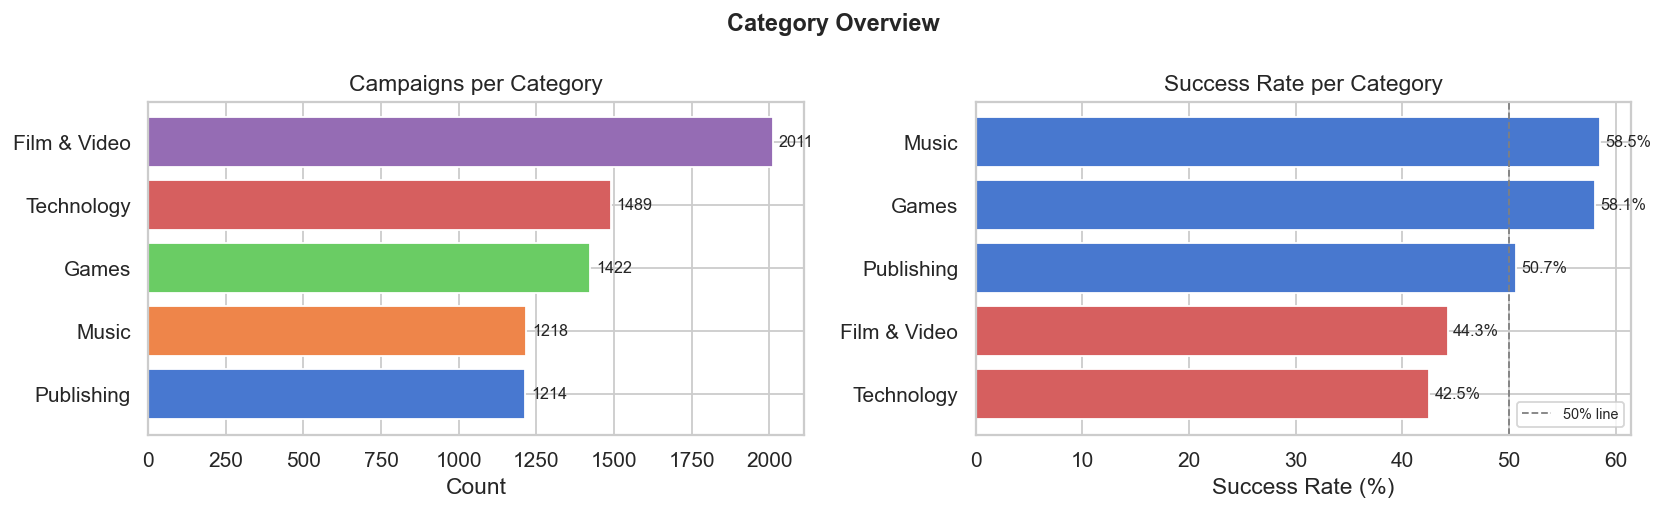

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Campaign count per category
cat_counts = df["category"].value_counts()
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
             color=sns.color_palette("muted", len(cat_counts)), edgecolor="white")
for i, v in enumerate(cat_counts.values[::-1]):
    axes[0].text(v + 20, i, str(v), va="center", fontsize=9)
axes[0].set_title("Campaigns per Category")
axes[0].set_xlabel("Count")

# Success rate per category
sr = df.groupby("category")["status"].mean().sort_values() * 100
colors = [BLUE if v >= 50 else RED for v in sr.values]
axes[1].barh(sr.index, sr.values, color=colors, edgecolor="white")
axes[1].axvline(50, color="grey", linestyle="--", linewidth=1, label="50% line")
for i, v in enumerate(sr.values):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
axes[1].set_title("Success Rate per Category")
axes[1].set_xlabel("Success Rate (%)")
axes[1].legend(fontsize=8)

plt.suptitle("Category Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_02_category_overview.png", bbox_inches="tight")
plt.show()


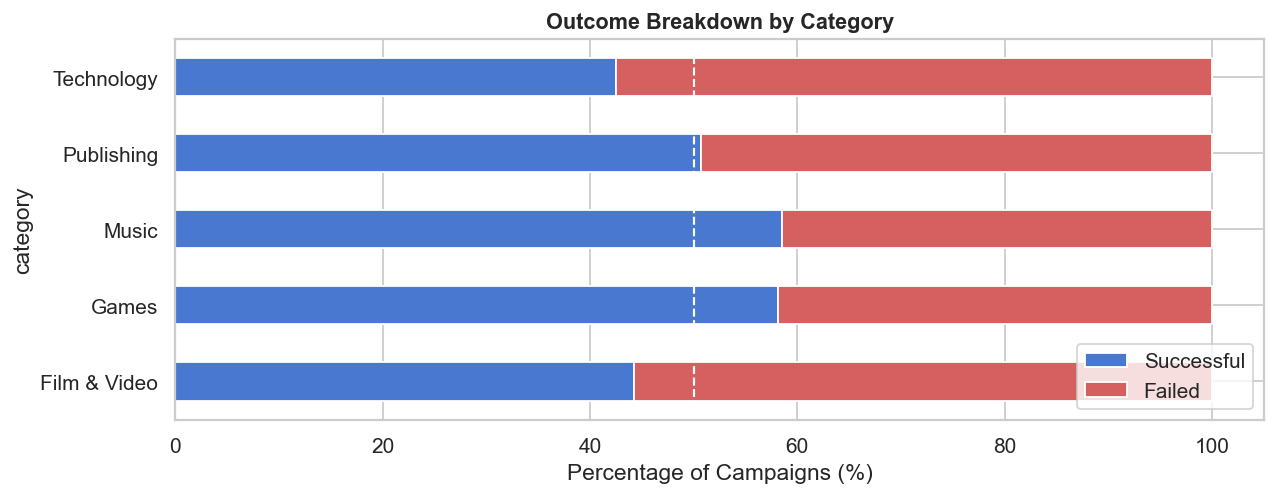

In [31]:
ct = df.groupby(["category", "outcome"]).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 4))
ct_pct[["Successful", "Failed"]].plot(
    kind="barh", stacked=True, color=PALETTE, edgecolor="white", ax=ax
)
ax.axvline(50, color="white", linestyle="--", linewidth=1.2)
ax.set_xlabel("Percentage of Campaigns (%)")
ax.set_title("Outcome Breakdown by Category", fontsize=12, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("eda_03_category_outcome_stack.png", bbox_inches="tight")
plt.show()


## 5. Funding Goal Distribution

With a mean of $25244, the graph showcases that most of the values are centered around the $15-$30k region. By outcome, we see that the median goal for successful projects is $11,870 and for failed projects its at $15,000. This means that successful projects tend to set a lower funding goal.

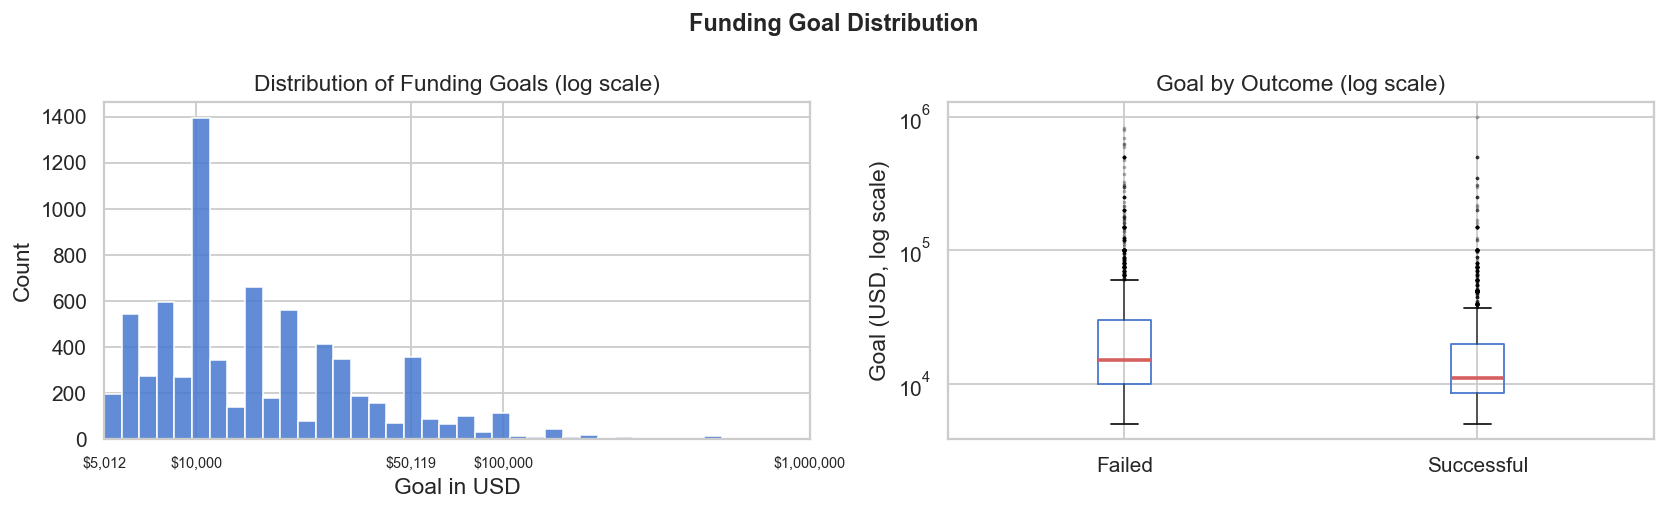

Median goal — Successful: $11,000  |  Failed: $15,000


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(np.log10(df["goal"]), bins=40, color=BLUE, edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Goal in USD")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Funding Goals (log scale)")
axes[0].margins(x=0)

xt = [3.7, 4, 4.7, 5, 6]   # ← starts at 3.7 (~$5,000) instead of 3 ($1,000)
axes[0].set_xticks(xt)
axes[0].set_xticklabels([f"${10**x:,.0f}" for x in xt], fontsize=8)
# Box plot by outcome
df.boxplot(column="goal", by="outcome", ax=axes[1],
           boxprops=dict(color=BLUE), medianprops=dict(color=RED, linewidth=2),
           flierprops=dict(marker=".", markersize=2, alpha=0.3))
axes[1].set_yscale("log")
axes[1].set_title("Goal by Outcome (log scale)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Goal (USD, log scale)")
plt.suptitle("")

plt.suptitle("Funding Goal Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_04_goal_distribution.png", bbox_inches="tight")
plt.show()

print("Median goal — Successful: ${:,.0f}  |  Failed: ${:,.0f}".format(
    df[df.status==1]["goal"].median(),
    df[df.status==0]["goal"].median()
))


## 6. Pledged Amount Distribution

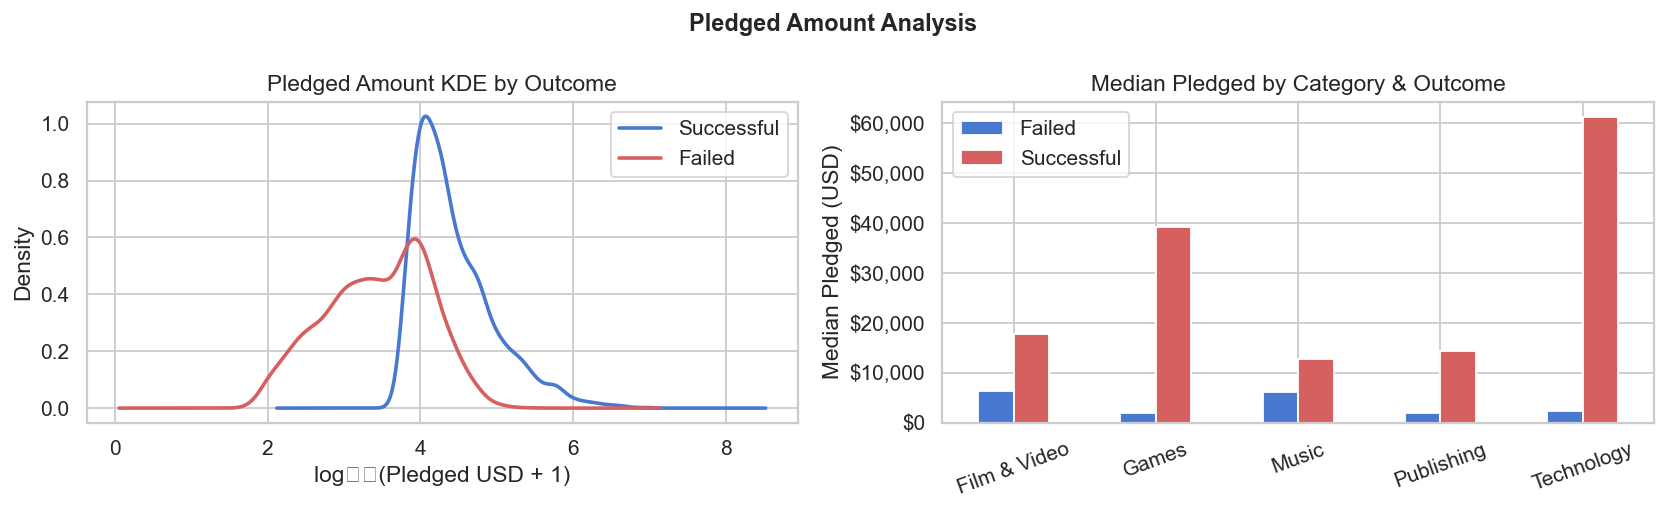

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# KDE by outcome on log scale
for label, color in zip(["Successful", "Failed"], PALETTE):
    sub = np.log10(df[df["outcome"] == label]["pledged"] + 1)
    sub.plot.kde(ax=axes[0], label=label, color=color, linewidth=2)
axes[0].set_xlabel("log₁₀(Pledged USD + 1)")
axes[0].set_title("Pledged Amount KDE by Outcome")
axes[0].legend()

# Median pledged per category
med_pledged = df.groupby(["category","outcome"])["pledged"].median().unstack()
med_pledged.plot(kind="bar", color=PALETTE, ax=axes[1], edgecolor="white")
axes[1].set_title("Median Pledged by Category & Outcome")
axes[1].set_xlabel("")
axes[1].set_ylabel("Median Pledged (USD)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.suptitle("Pledged Amount Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_05_pledged_distribution.png", bbox_inches="tight")
plt.show()


## 7. Reached % Distribution

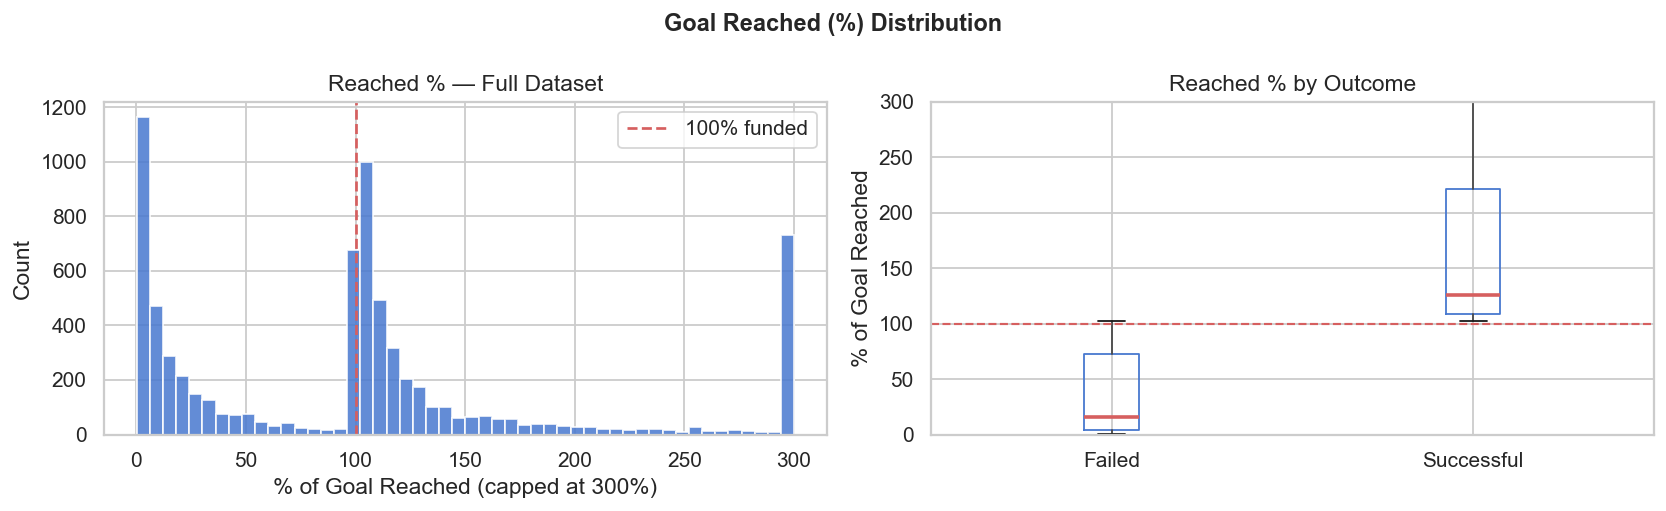

Median reached% — Successful: 125.8%  |  Failed: 16.0%


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall histogram (capped at 300% for readability)
cap = df["reached"].clip(upper=300)
axes[0].hist(cap, bins=50, color=BLUE, edgecolor="white", alpha=0.85)
axes[0].axvline(100, color=RED, linestyle="--", linewidth=1.5, label="100% funded")
axes[0].set_xlabel("% of Goal Reached (capped at 300%)")
axes[0].set_ylabel("Count")
axes[0].set_title("Reached % — Full Dataset")
axes[0].legend()

# Box plot by category
df.boxplot(column="reached", by="outcome", ax=axes[1],
           boxprops=dict(color=BLUE), medianprops=dict(color=RED, linewidth=2),
           flierprops=dict(marker=".", markersize=2, alpha=0.3))
axes[1].set_ylim(0, 300)
axes[1].axhline(100, color=RED, linestyle="--", linewidth=1.2)
axes[1].set_title("Reached % by Outcome")
axes[1].set_xlabel("")
axes[1].set_ylabel("% of Goal Reached")
plt.suptitle("")

plt.suptitle("Goal Reached (%) Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_06_reached_distribution.png", bbox_inches="tight")
plt.show()

print("Median reached% — Successful: {:.1f}%  |  Failed: {:.1f}%".format(
    df[df.status==1]["reached"].median(),
    df[df.status==0]["reached"].median()
))


## 8. Goal vs. Pledged

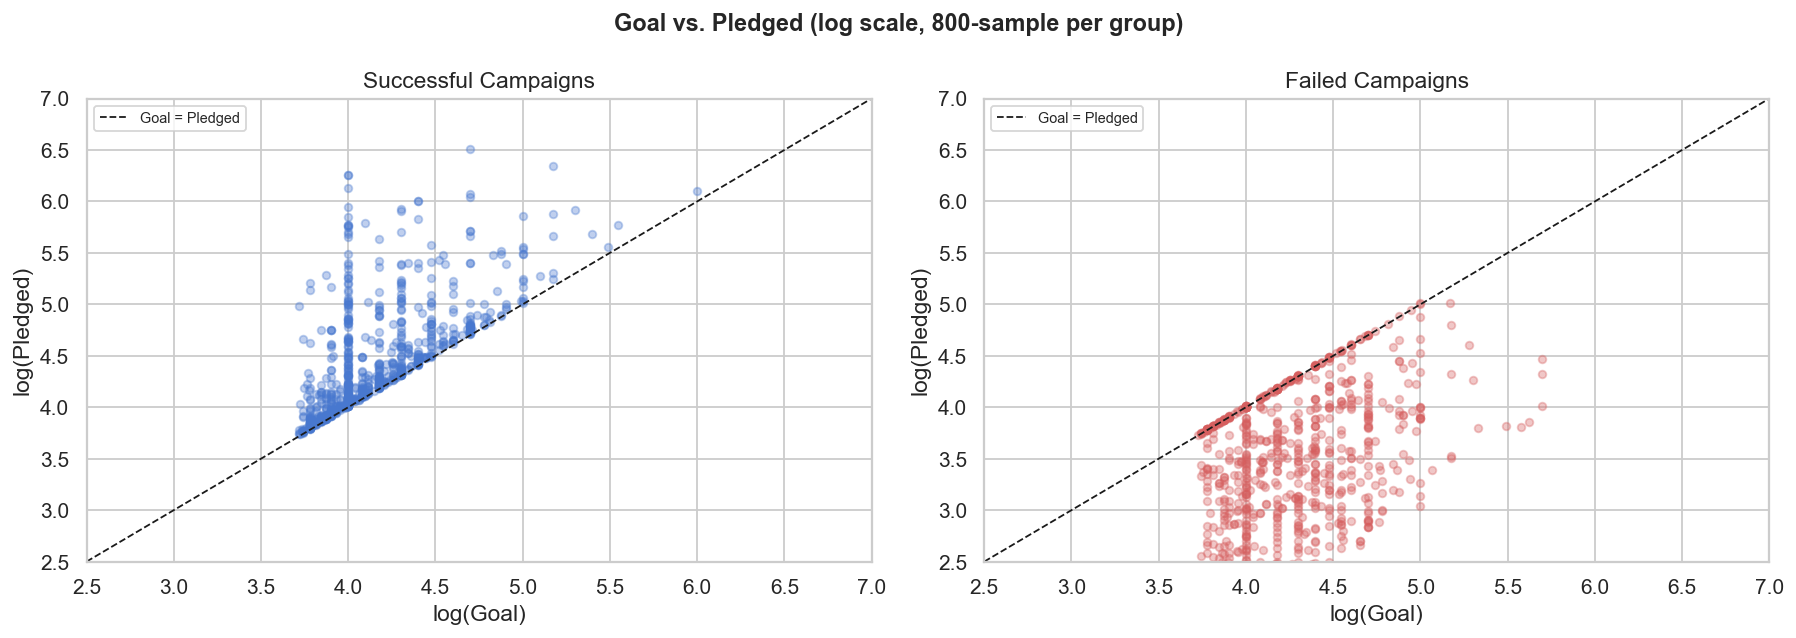

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, color) in zip(axes, zip(["Successful","Failed"], PALETTE)):
    sub = df[df["outcome"] == label].sample(min(800, len(df)), random_state=42)
    ax.scatter(np.log10(sub["goal"]+1), np.log10(sub["pledged"]+1),
               alpha=0.35, s=18, color=color)
    # identity line
    lims = [2.5, 7]
    ax.plot(lims, lims, "k--", linewidth=1, label="Goal = Pledged")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("log(Goal)")
    ax.set_ylabel("log(Pledged)")
    ax.set_title(f"{label} Campaigns")
    ax.legend(fontsize=8)

plt.suptitle("Goal vs. Pledged (log scale, 800-sample per group)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_07_goal_vs_pledged.png", bbox_inches="tight")
plt.show()


## 9. Description Length Analysis

We measure description length two ways:
- **Character count** — total characters in the raw description
- **Word count** — whitespace-split word tokens


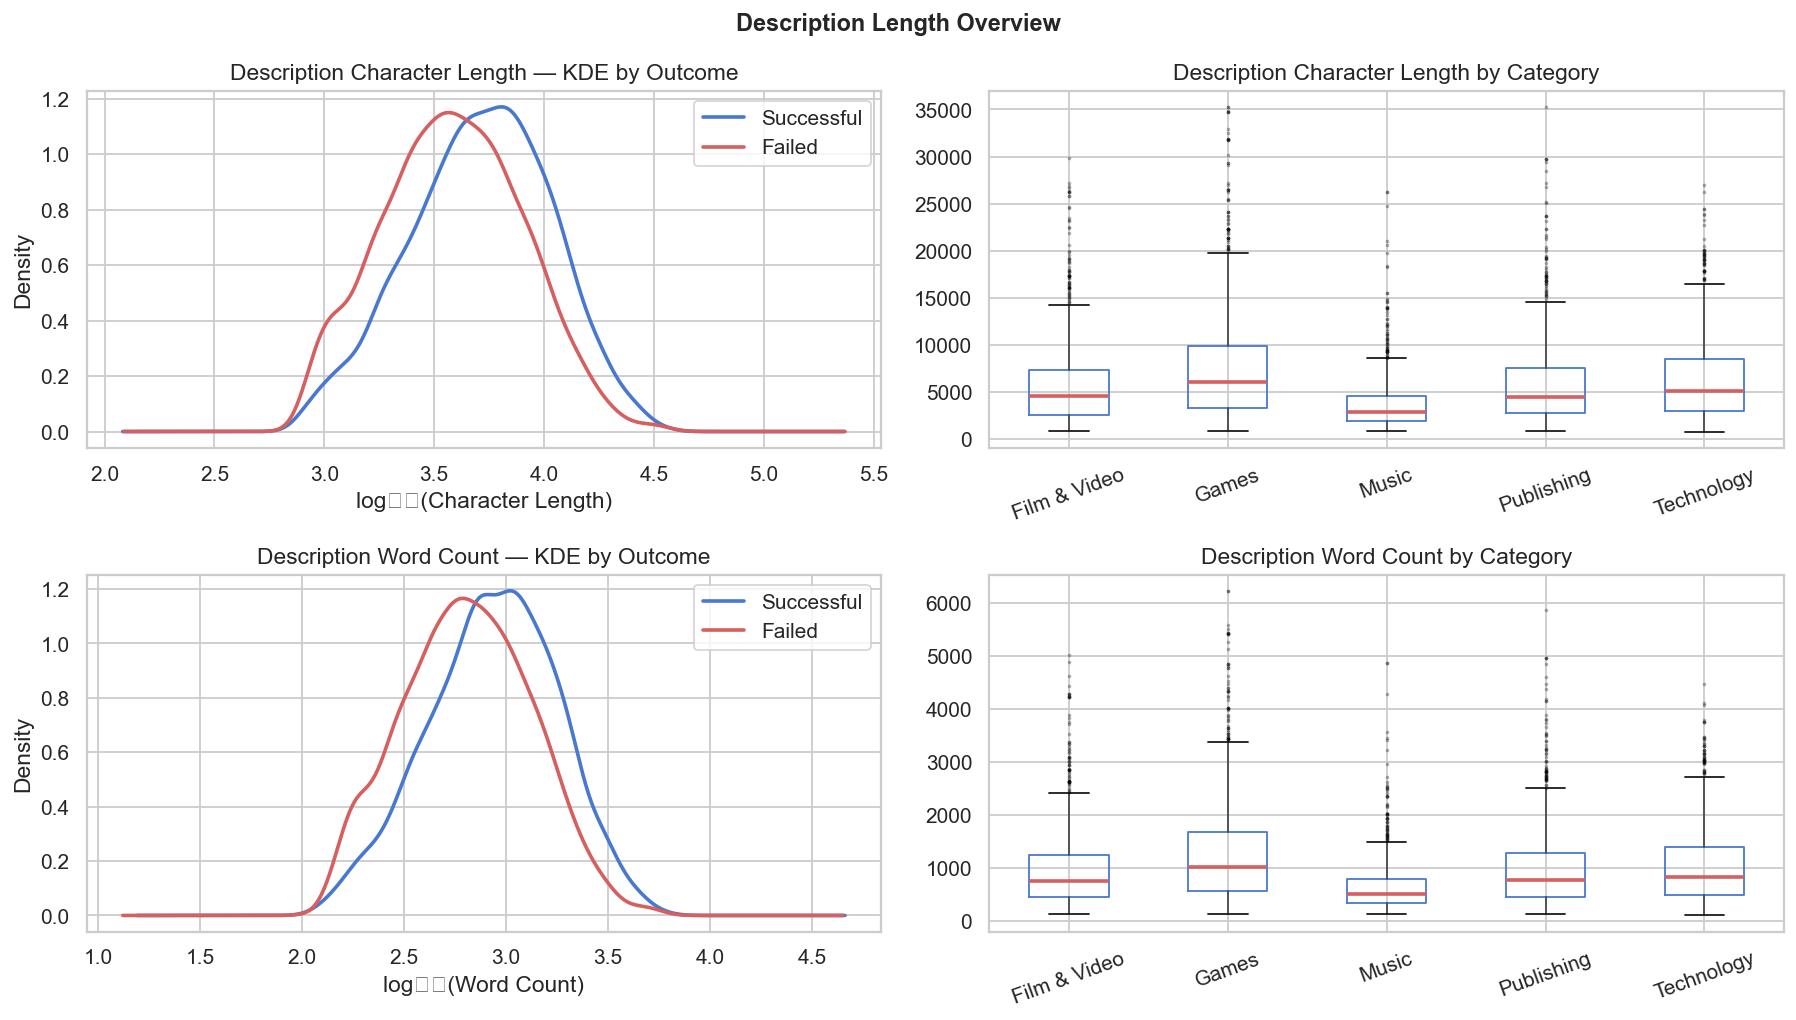

=== Description Word Count by Outcome ===


,count,mean,std,min,25%,50%,75%,max
outcome,,,,,,,,
Failed,3677.0,839.6,674.7,101.0,382.0,641.0,1078.0,5881.0
Successful,3677.0,1112.4,820.9,115.0,532.0,892.0,1460.0,6237.0


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, label, row in zip(
    ["desc_char_len", "desc_word_len"],
    ["Character Length", "Word Count"],
    [0, 1]
):
    # KDE by outcome
    for outcome, color in zip(["Successful","Failed"], PALETTE):
        vals = np.log10(df[df["outcome"]==outcome][col].clip(lower=1))
        vals.plot.kde(ax=axes[row][0], label=outcome, color=color, linewidth=2)
    axes[row][0].set_xlabel(f"log₁₀({label})")
    axes[row][0].set_title(f"Description {label} — KDE by Outcome")
    axes[row][0].legend()

    # Box plot by category
    df.boxplot(column=col, by="category", ax=axes[row][1],
               boxprops=dict(color=BLUE),
               medianprops=dict(color=RED, linewidth=2),
               flierprops=dict(marker=".", markersize=2, alpha=0.3))
    axes[row][1].set_title(f"Description {label} by Category")
    axes[row][1].set_xlabel("")
    axes[row][1].tick_params(axis="x", rotation=20)
    plt.suptitle("")

plt.suptitle("Description Length Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_08_desc_length_overview.png", bbox_inches="tight")
plt.show()

print("=== Description Word Count by Outcome ===")
display(df.groupby("outcome")["desc_word_len"].describe().round(1))


## 10. Description Length vs. Amount Funded

We examine whether longer campaign descriptions are associated with higher pledged amounts,
using both **scatter plots** and **binned median plots** for a cleaner signal.
Statistical tests (Pearson & Spearman correlations) are reported for each group.

There is a **modest positive** correlation between description length and amount funded overall, with a non-linear relationship that differs by category. The correlation coefficient is higher for successful projects, indicating that more elaborate descriptions were rewarded, but length alone cannot be used to determine whether a project can succeed. 

*Technology* having the highest overall and failure correlation can be used to infer that backers prefer simpler and concise descriptions for this category


In [38]:
def annotate_corr(ax, x, y, loc=(0.04, 0.93)):
    mask = np.isfinite(x) & np.isfinite(y)
    r_p, p_p = stats.pearsonr(x[mask], y[mask])
    r_s, p_s = stats.spearmanr(x[mask], y[mask])
    
    # Use parentheses to wrap the multi-line string
    txt = (
        f"Pearson r = {r_p:+.3f} (p={'<0.001' if p_p<0.001 else f'{p_p:.3f}'})\n"
        f"Spearman ρ = {r_s:+.3f} (p={'<0.001' if p_s<0.001 else f'{p_s:.3f}'})"
    )
    
    ax.text(*loc, txt, transform=ax.transAxes, fontsize=8,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))


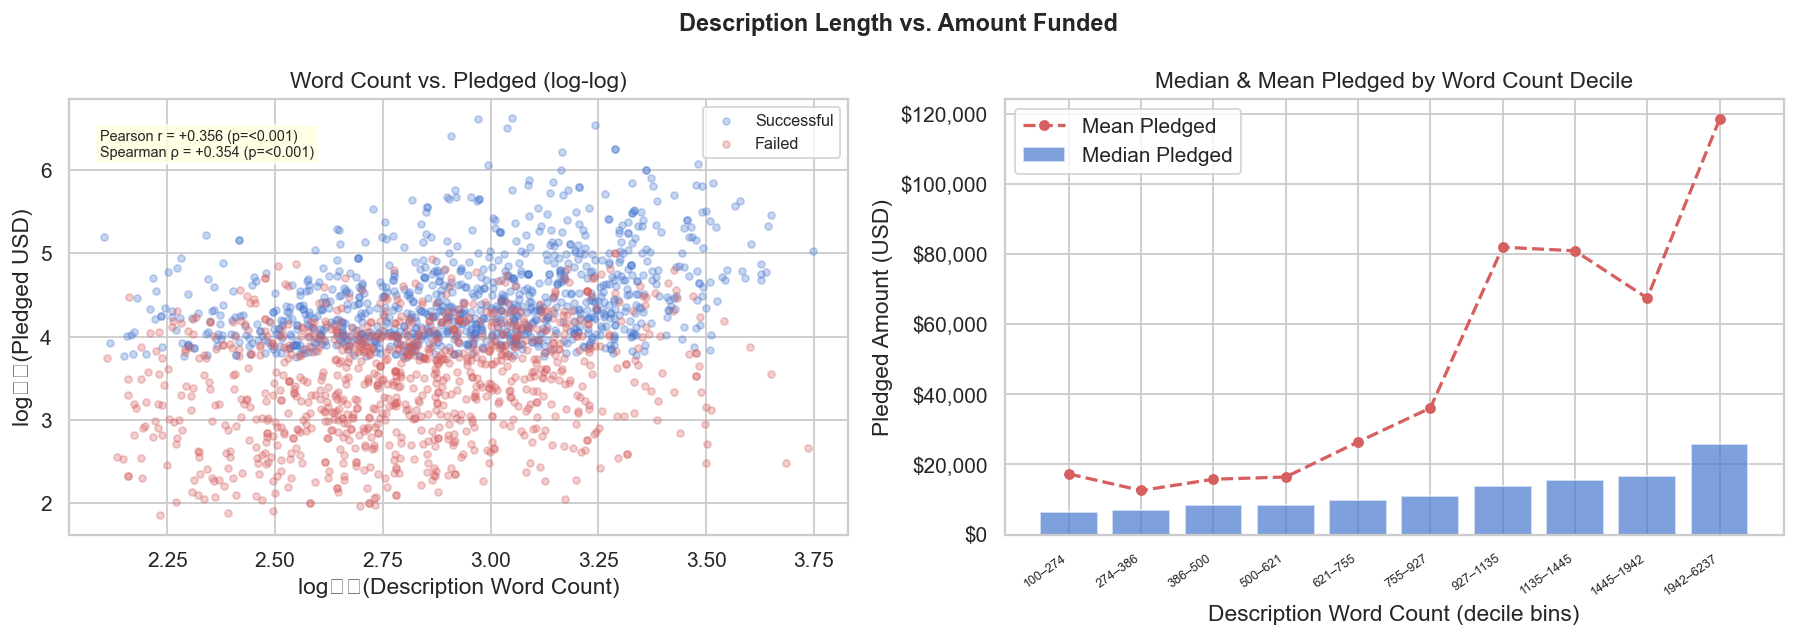

In [39]:
# ── Fig A: Scatter — word count vs pledged (log-log), coloured by outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df.sample(min(2000, len(df)), random_state=42)
for outcome, color in zip(["Successful","Failed"], PALETTE):
    sub = sample[sample["outcome"]==outcome]
    axes[0].scatter(np.log10(sub["desc_word_len"].clip(lower=1)),
                    np.log10(sub["pledged"].clip(lower=1)),
                    alpha=0.3, s=15, color=color, label=outcome)
axes[0].set_xlabel("log₁₀(Description Word Count)")
axes[0].set_ylabel("log₁₀(Pledged USD)")
axes[0].set_title("Word Count vs. Pledged (log-log)")
axes[0].legend(fontsize=9)
annotate_corr(axes[0],
              np.log10(sample["desc_word_len"].clip(lower=1).values),
              np.log10(sample["pledged"].clip(lower=1).values))

# ── Binned median plot (all data)
df["word_len_bin"] = pd.qcut(df["desc_word_len"], q=10, duplicates="drop")
bin_stats = df.groupby("word_len_bin", observed=True).agg(
    median_pledged=("pledged", "median"),
    mean_pledged=("pledged", "mean"),
    n=("pledged", "count"),
    success_rate=("status", "mean")
).reset_index()
bin_stats["bin_mid"] = bin_stats["word_len_bin"].apply(lambda x: (x.left + x.right) / 2)

ax2 = axes[1]
ax2.bar(range(len(bin_stats)), bin_stats["median_pledged"],
        color=BLUE, alpha=0.7, label="Median Pledged")
ax2.plot(range(len(bin_stats)), bin_stats["mean_pledged"],
         "o--", color=RED, linewidth=1.8, markersize=5, label="Mean Pledged")
ax2.set_xticks(range(len(bin_stats)))
ax2.set_xticklabels(
    [f"{int(b.left)}–{int(b.right)}" for b in bin_stats["word_len_bin"]],
    rotation=35, ha="right", fontsize=7
)
ax2.set_xlabel("Description Word Count (decile bins)")
ax2.set_ylabel("Pledged Amount (USD)")
ax2.set_title("Median & Mean Pledged by Word Count Decile")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.legend()

plt.suptitle("Description Length vs. Amount Funded", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_09_desc_len_vs_pledged.png", bbox_inches="tight")
plt.show()


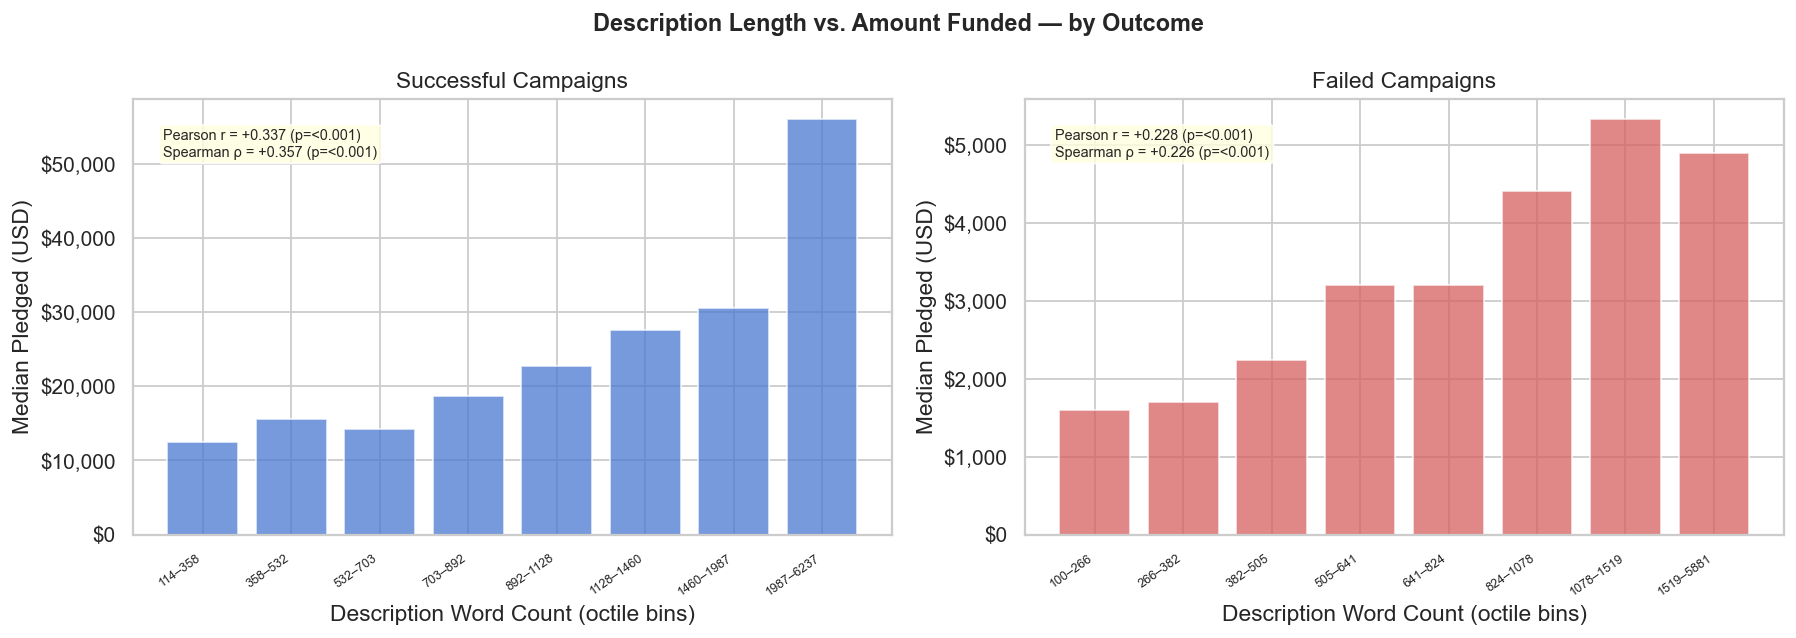

In [40]:
# ── Fig B: Same analysis split by outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, outcome, color in zip(axes, ["Successful","Failed"], PALETTE):
    sub = df[df["outcome"]==outcome].copy()
    sub["word_len_bin"] = pd.qcut(sub["desc_word_len"], q=8, duplicates="drop")
    bstats = sub.groupby("word_len_bin", observed=True).agg(
        median_pledged=("pledged","median"),
        n=("pledged","count")
    ).reset_index()

    ax.bar(range(len(bstats)), bstats["median_pledged"],
           color=color, alpha=0.75, edgecolor="white")
    ax.set_xticks(range(len(bstats)))
    ax.set_xticklabels(
        [f"{int(b.left)}–{int(b.right)}" for b in bstats["word_len_bin"]],
        rotation=35, ha="right", fontsize=7
    )
    ax.set_xlabel("Description Word Count (octile bins)")
    ax.set_ylabel("Median Pledged (USD)")
    ax.set_title(f"{outcome} Campaigns")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

    # correlation within this group
    annotate_corr(ax,
                  np.log10(sub["desc_word_len"].clip(lower=1).values),
                  np.log10(sub["pledged"].clip(lower=1).values))

plt.suptitle("Description Length vs. Amount Funded — by Outcome",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_10_desc_len_vs_pledged_by_outcome.png", bbox_inches="tight")
plt.show()


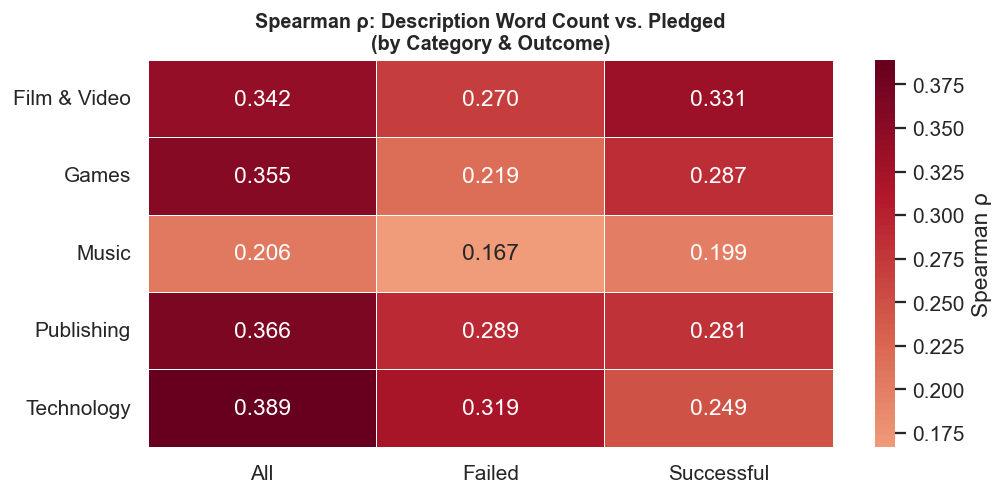


Full correlation table:


,category,group,spearman_rho,p_value
0,Film & Video,All,0.342,0.0000
1,Film & Video,Failed,0.270,0.0000
2,Film & Video,Successful,0.331,0.0000
3,Games,All,0.355,0.0000
4,Games,Failed,0.219,0.0000
5,Games,Successful,0.287,0.0000
6,Music,All,0.206,0.0000
7,Music,Failed,0.167,0.0002
8,Music,Successful,0.199,0.0000
9,Publishing,All,0.366,0.0000


In [41]:
# ── Fig C: Per-category correlation heatmap
corr_rows = []
for cat in df["category"].unique():
    for outcome in ["Successful", "Failed", "All"]:
        sub = df[df["category"]==cat] if outcome=="All" else df[(df["category"]==cat)&(df["outcome"]==outcome)]
        if len(sub) < 30:
            continue
        x = np.log10(sub["desc_word_len"].clip(lower=1))
        y = np.log10(sub["pledged"].clip(lower=1))
        r, p = stats.spearmanr(x, y)
        corr_rows.append({"category": cat, "group": outcome, "spearman_rho": round(r,3), "p_value": round(p,4)})

corr_df = pd.DataFrame(corr_rows)
pivot = corr_df.pivot(index="category", columns="group", values="spearman_rho")

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", center=0,
            cmap="RdBu_r", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Spearman ρ"})
ax.set_title("Spearman ρ: Description Word Count vs. Pledged\n(by Category & Outcome)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("eda_11_corr_heatmap.png", bbox_inches="tight")
plt.show()

print("\nFull correlation table:")
display(corr_df.sort_values(["category","group"]).reset_index(drop=True))
